# Análisis de Evaluación de Sistemas de Recomendación

Este notebook analiza los resultados de la evaluación offline de diferentes estrategias de recomendación usando múltiples métricas.

> Resultados obtenidos con `python -m offline_recommender.evaluate_recommender` usando: `--min-ratings 30 --holdout-ratio 0.2 --k 9 --pool-size 500`.

## Métricas evaluadas:
- **NDCG@9**: Normalized Discounted Cumulative Gain
- **Precision@9**: Proporción de recomendaciones relevantes
- **Recall@9**: Proporción de items relevantes recuperados
- **F1@9**: Media armónica de Precision y Recall
- **MRR**: Mean Reciprocal Rank (posición del primer item relevante)
- **Genre Diversity**: Diversidad de géneros en las recomendaciones
- **Artist Diversity**: Diversidad de artistas en las recomendaciones
- **Novelty**: Novedad basada en popularidad (-log2)

## Estrategias evaluadas:
- **max_ensemble**: Sistema Max-Ensemble (toma el score máximo de cada estrategia)
- **rrf_ensemble**: Reciprocal Rank Fusion (combina rankings por consenso)
- **hybrid**: Sistema híbrido tradicional (baseline de comparación)
- **advanced**: Recomendaciones avanzadas (NMF + Two Towers combinados)
- **nmf**: Factorización matricial (NMF)
- **two_towers**: Two Towers (Deep Learning)
- **pairs**: Co-ocurrencia (release_pairs)
- **content**: Perfiles de contenido
- **random**: Exploración aleatoria (baseline)
- **popular**: Popularidad (baseline)

In [31]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


# Control simple para warnings molestos
SUPPRESS_WARNINGS = True
if SUPPRESS_WARNINGS:
    warnings.filterwarnings("ignore")

# Configurar estilo
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 11

# Cargar datos
csv_path = Path("../offline_recommender/output/rrf_vs_max.csv")
df = pd.read_csv(csv_path)

print(f"📊 Datos cargados: {len(df)} usuarios evaluados")
print(f"📈 Columnas: {len(df.columns)}")
print("\nPrimeras filas:")
df.head()

📊 Datos cargados: 3375 usuarios evaluados
📈 Columnas: 82

Primeras filas:


,user_id,holdout_size,hybrid_ndcg,hybrid_precision,hybrid_recall,hybrid_f1,hybrid_mrr,hybrid_genre_diversity,hybrid_artist_diversity,hybrid_novelty,...,random_artist_diversity,random_novelty,popular_ndcg,popular_precision,popular_recall,popular_f1,popular_mrr,popular_genre_diversity,popular_artist_diversity,popular_novelty
0,februarystars57,8,0.000000,0.000000,0.000000,0.000000,0.0,0.555556,0.222222,1.560719,...,1.0,11.255723,1.0,0.111111,0.125,0.117647,1.0,1.444444,0.666667,0.314409
1,untitled1,9,0.000000,0.000000,0.000000,0.000000,0.0,1.777778,0.888889,2.462058,...,1.0,11.830108,0.0,0.000000,0.000,0.000000,0.0,1.111111,0.444444,0.252914
2,Thomthumb,16,0.000000,0.000000,0.000000,0.000000,0.0,0.777778,0.333333,1.760441,...,1.0,12.552120,0.0,0.000000,0.000,0.000000,0.0,1.333333,0.555556,0.224018
3,Arayhenry81,10,0.000000,0.000000,0.000000,0.000000,0.0,1.111111,0.888889,3.420546,...,1.0,11.891331,0.0,0.000000,0.000,0.000000,0.0,1.333333,0.555556,0.224018
4,silvermetal007,17,0.967468,0.333333,0.176471,0.230769,1.0,0.888889,0.555556,0.909647,...,1.0,12.742810,0.0,0.000000,0.000,0.000000,0.0,1.333333,0.555556,0.290052


In [32]:
# Definir estrategias y métricas
strategies = [
    "max_ensemble",
    "rrf_ensemble",
    "hybrid",
    "advanced",
    "nmf",
    "two_towers",
    "pairs",
    "content",
    "random",
    "popular",
]
metrics = [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]

# Calcular estadísticas descriptivas por estrategia y métrica
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS POR ESTRATEGIA")
print("=" * 80)

for strategy in strategies:
    print(f"\n{strategy.upper()}:")
    print("-" * 40)
    for metric in metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            values = df[col].dropna()
            if len(values) > 0:
                print(
                    f"  {metric:20s}: mean={values.mean():.4f}  std={values.std():.4f}  min={values.min():.4f}  max={values.max():.4f}"
                )

ESTADÍSTICAS DESCRIPTIVAS POR ESTRATEGIA

MAX_ENSEMBLE:
----------------------------------------
  ndcg                : mean=0.5528  std=0.3508  min=0.0000  max=1.0000
  precision           : mean=0.2009  std=0.1830  min=0.0000  max=1.0000
  recall              : mean=0.0687  std=0.0725  min=0.0000  max=0.5000
  f1                  : mean=0.0869  std=0.0790  min=0.0000  max=0.4800
  mrr                 : mean=0.4921  std=0.3930  min=0.0000  max=1.0000
  genre_diversity     : mean=1.7925  std=0.2732  min=0.5556  max=2.5556
  artist_diversity    : mean=0.9999  std=0.0077  min=0.5556  max=1.0000
  novelty             : mean=1.1469  std=0.5767  min=0.2240  max=4.8941

RRF_ENSEMBLE:
----------------------------------------
  ndcg                : mean=0.5714  std=0.3710  min=0.0000  max=1.0000
  precision           : mean=0.1961  std=0.1830  min=0.0000  max=1.0000
  recall              : mean=0.0670  std=0.0731  min=0.0000  max=0.5000
  f1                  : mean=0.0845  std=0.0788  min=0.

In [33]:
# Crear DataFrame con promedios por estrategia
summary_data = []
for strategy in strategies:
    row = {"strategy": strategy}
    for metric in metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            row[metric] = df[col].mean()
        else:
            row[metric] = 0.0
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index("strategy")

print("=" * 80)
print("PROMEDIOS POR ESTRATEGIA")
print("=" * 80)
print(summary_df.round(4))

PROMEDIOS POR ESTRATEGIA
                ndcg  precision  recall      f1     mrr  genre_diversity  \
strategy                                                                   
max_ensemble  0.5528     0.2009  0.0687  0.0869  0.4921           1.7925   
rrf_ensemble  0.5714     0.1961  0.0670  0.0845  0.5347           1.6633   
hybrid        0.3352     0.1240  0.0371  0.0476  0.2995           1.1188   
advanced      0.3156     0.1198  0.0322  0.0431  0.2766           1.0955   
nmf           0.2118     0.0734  0.0239  0.0310  0.1781           0.9589   
two_towers    0.2922     0.1119  0.0291  0.0390  0.2463           1.1591   
pairs         0.5437     0.1916  0.0628  0.0801  0.5197           1.3337   
content       0.3819     0.1000  0.0487  0.0568  0.3598           0.4359   
random        0.0004     0.0001  0.0000  0.0000  0.0002           1.7500   
popular       0.2043     0.0716  0.0182  0.0244  0.1645           1.3049   

              artist_diversity  novelty  
strategy            

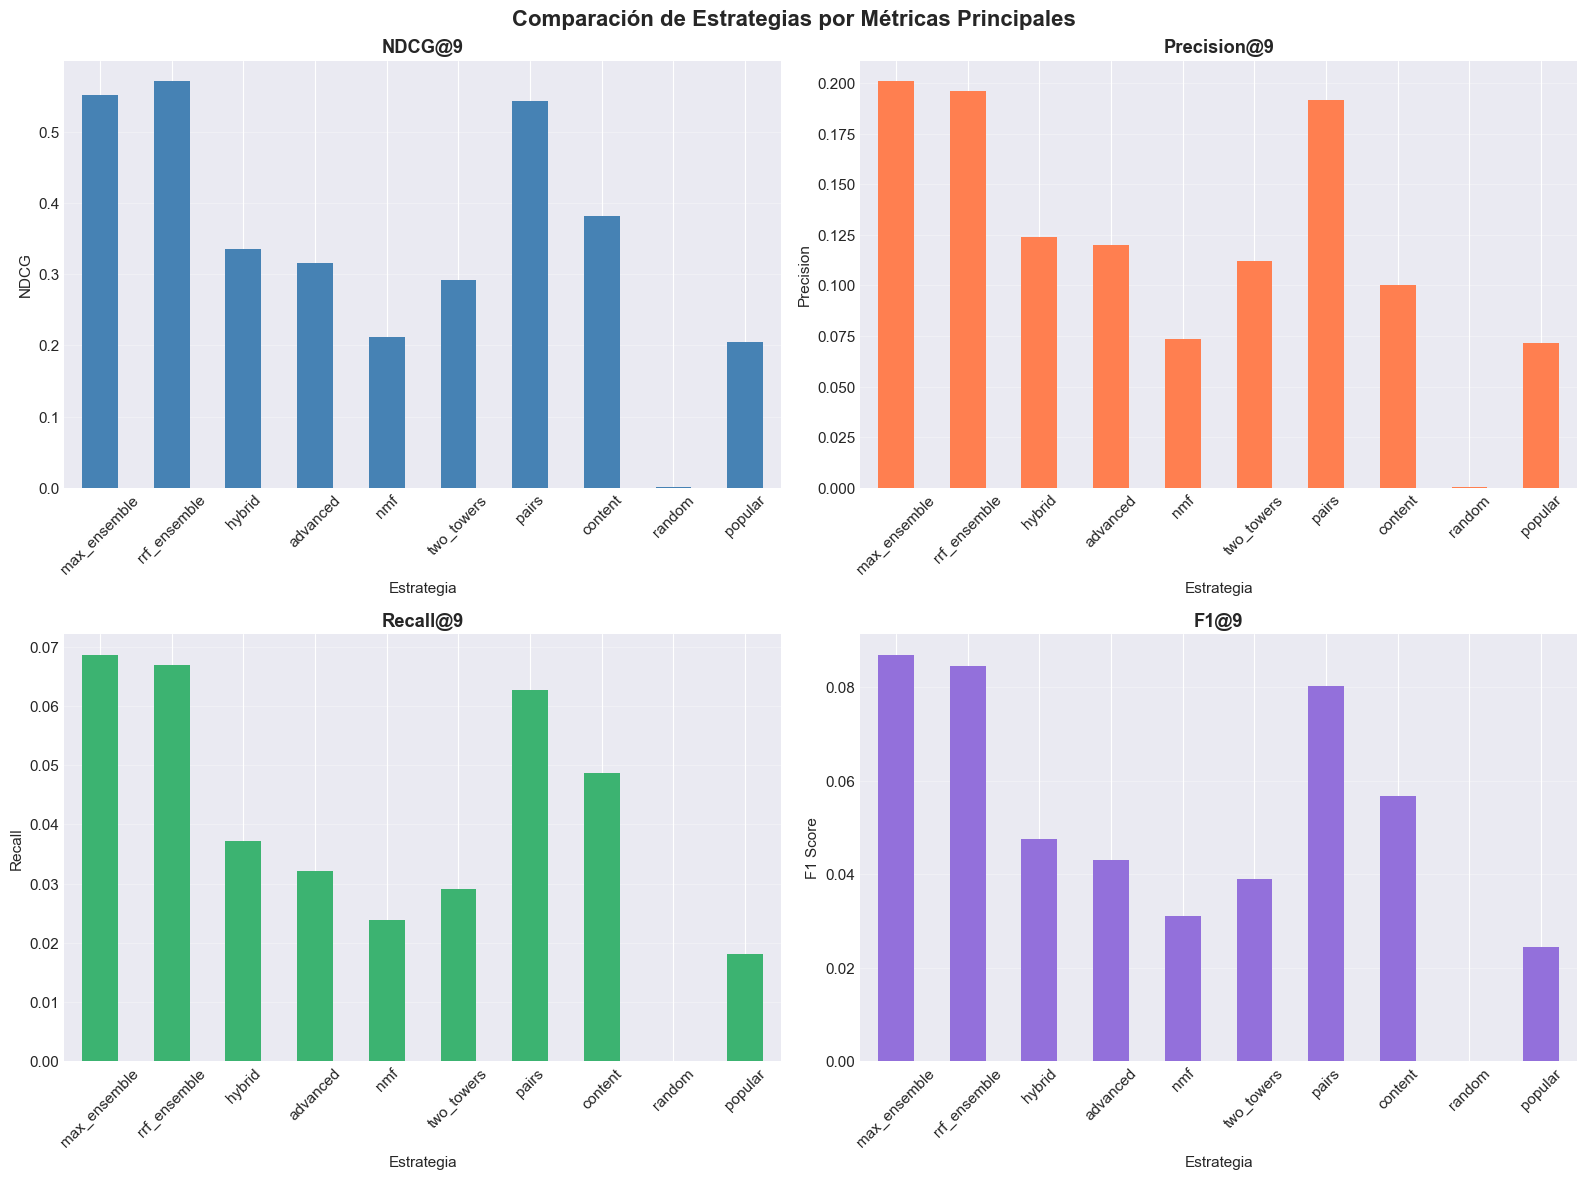

In [34]:
# Visualización 1: Comparación de métricas principales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparación de Estrategias por Métricas Principales", fontsize=16, fontweight="bold")

# NDCG
ax1 = axes[0, 0]
summary_df["ndcg"].plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_title("NDCG@9", fontweight="bold")
ax1.set_ylabel("NDCG")
ax1.set_xlabel("Estrategia")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)

# Precision
ax2 = axes[0, 1]
summary_df["precision"].plot(kind="bar", ax=ax2, color="coral")
ax2.set_title("Precision@9", fontweight="bold")
ax2.set_ylabel("Precision")
ax2.set_xlabel("Estrategia")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

# Recall
ax3 = axes[1, 0]
summary_df["recall"].plot(kind="bar", ax=ax3, color="mediumseagreen")
ax3.set_title("Recall@9", fontweight="bold")
ax3.set_ylabel("Recall")
ax3.set_xlabel("Estrategia")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y", alpha=0.3)

# F1
ax4 = axes[1, 1]
summary_df["f1"].plot(kind="bar", ax=ax4, color="mediumpurple")
ax4.set_title("F1@9", fontweight="bold")
ax4.set_ylabel("F1 Score")
ax4.set_xlabel("Estrategia")
ax4.tick_params(axis="x", rotation=45)
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

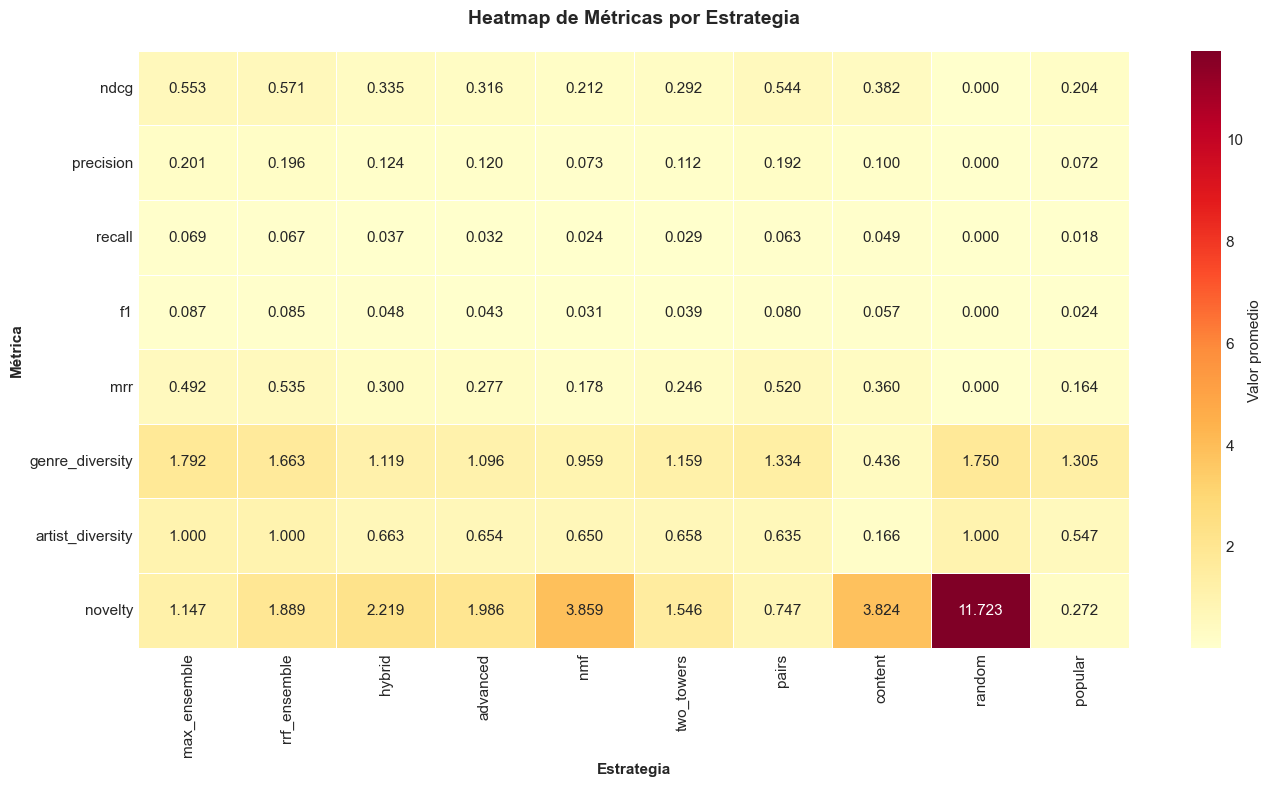

In [35]:
# Visualización 2: Heatmap de todas las métricas
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    summary_df.T,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    cbar_kws={"label": "Valor promedio"},
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Heatmap de Métricas por Estrategia", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Estrategia", fontweight="bold")
ax.set_ylabel("Métrica", fontweight="bold")
plt.tight_layout()
plt.show()

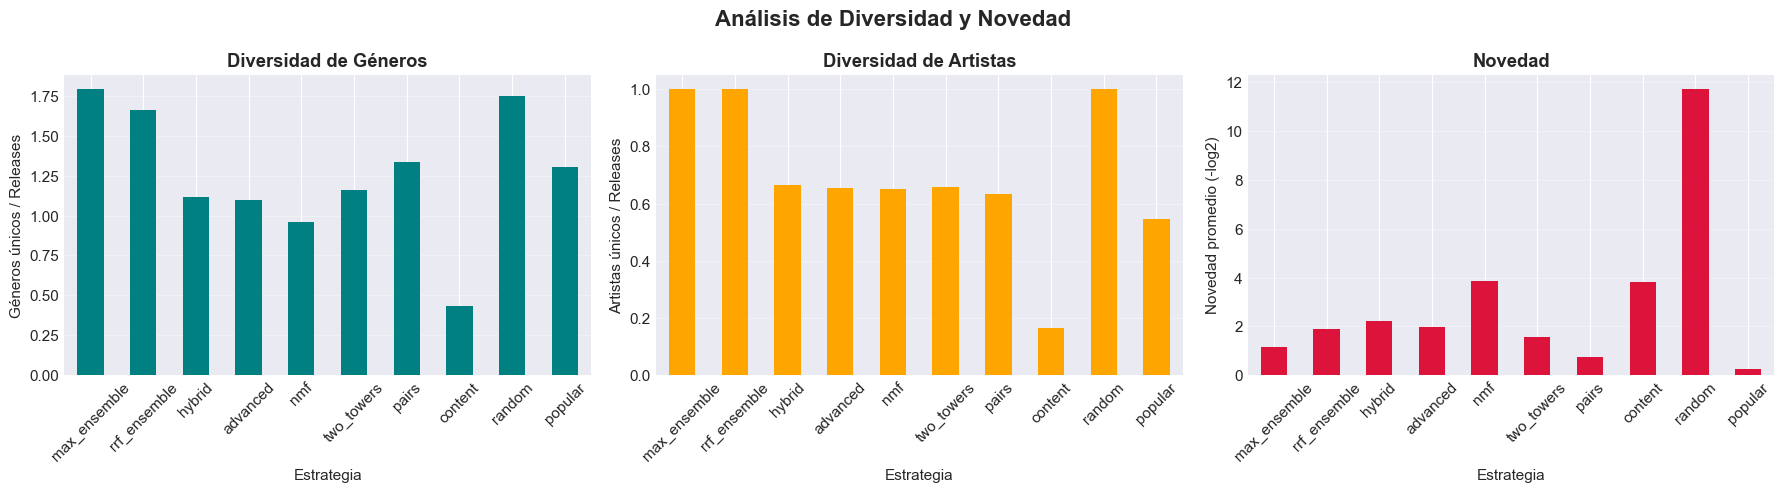

In [36]:
# Visualización 3: Diversidad y Novedad
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de Diversidad y Novedad", fontsize=16, fontweight="bold")

# Genre Diversity
ax1 = axes[0]
summary_df["genre_diversity"].plot(kind="bar", ax=ax1, color="teal")
ax1.set_title("Diversidad de Géneros", fontweight="bold")
ax1.set_ylabel("Géneros únicos / Releases")
ax1.set_xlabel("Estrategia")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)

# Artist Diversity
ax2 = axes[1]
summary_df["artist_diversity"].plot(kind="bar", ax=ax2, color="orange")
ax2.set_title("Diversidad de Artistas", fontweight="bold")
ax2.set_ylabel("Artistas únicos / Releases")
ax2.set_xlabel("Estrategia")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

# Novelty
ax3 = axes[2]
summary_df["novelty"].plot(kind="bar", ax=ax3, color="crimson")
ax3.set_title("Novedad", fontweight="bold")
ax3.set_ylabel("Novedad promedio (-log2)")
ax3.set_xlabel("Estrategia")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

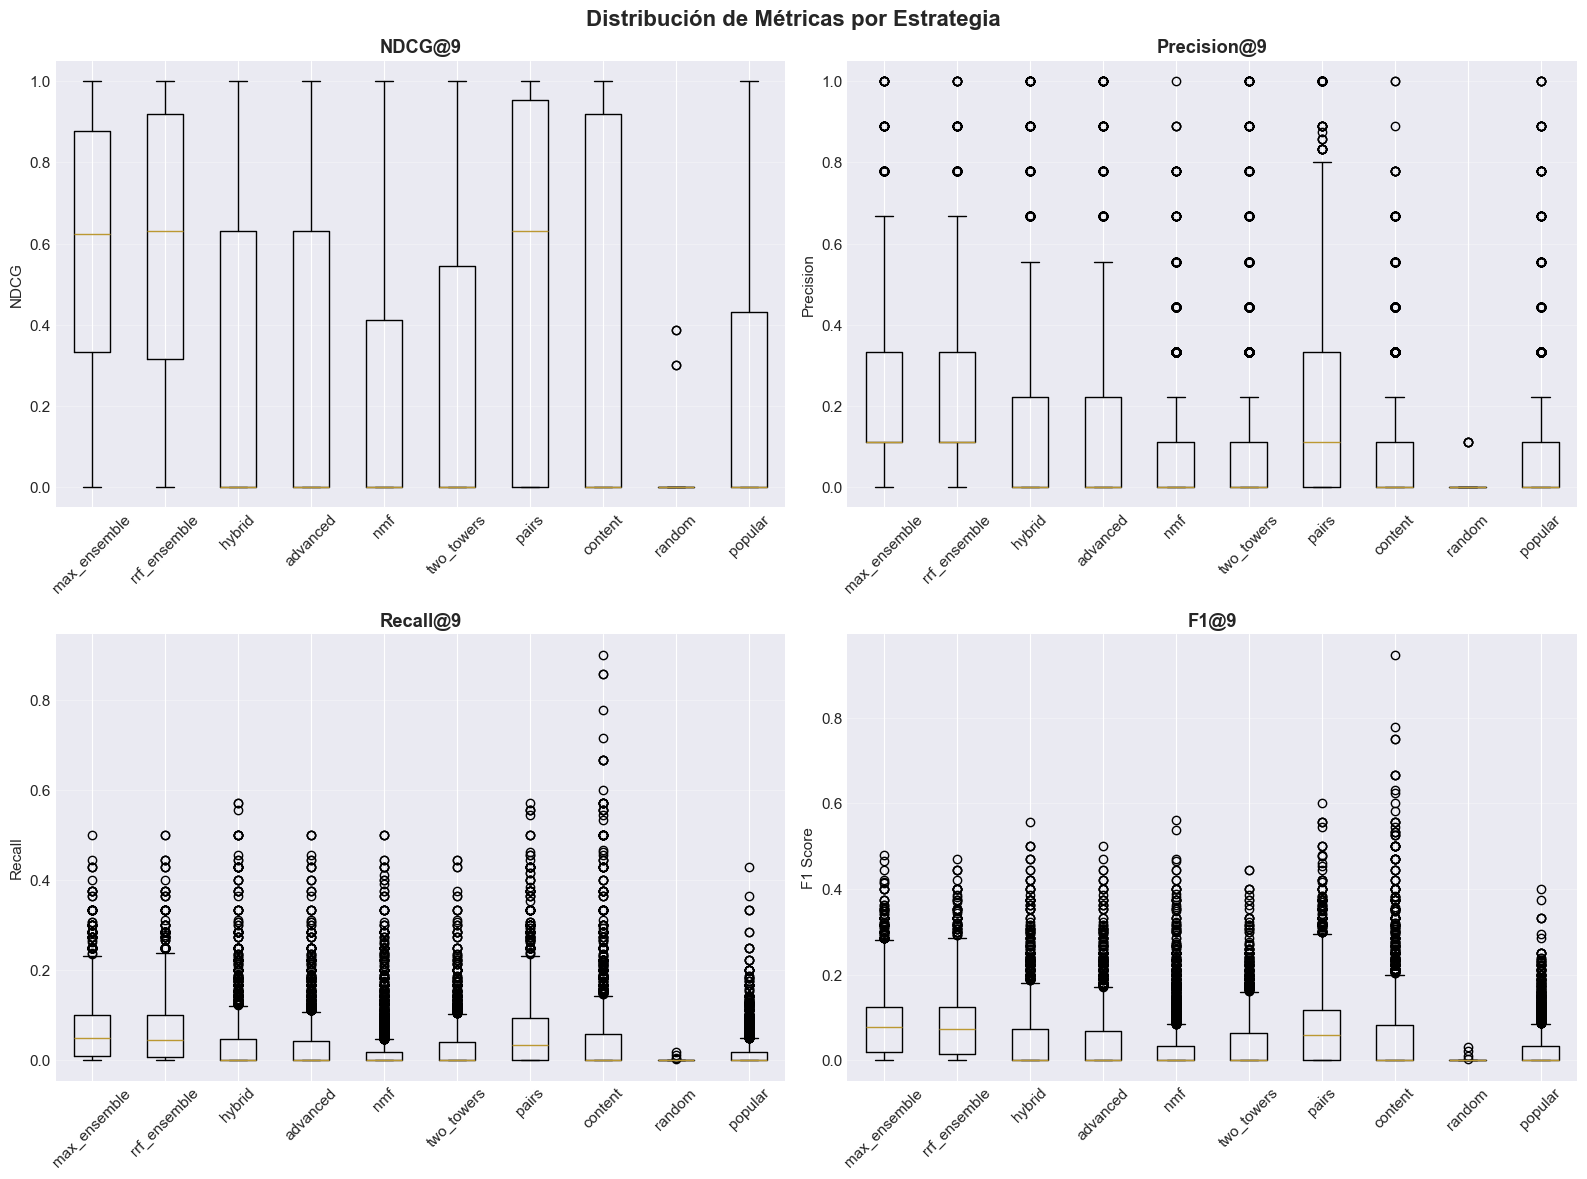

In [37]:
# Visualización 4: Boxplots de distribución de métricas principales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distribución de Métricas por Estrategia", fontsize=16, fontweight="bold")

# Preparar datos para boxplots
ndcg_data = [df[f"{s}_ndcg"].dropna() for s in strategies]
precision_data = [df[f"{s}_precision"].dropna() for s in strategies]
recall_data = [df[f"{s}_recall"].dropna() for s in strategies]
f1_data = [df[f"{s}_f1"].dropna() for s in strategies]

# NDCG
axes[0, 0].boxplot(ndcg_data, labels=strategies)
axes[0, 0].set_title("NDCG@9", fontweight="bold")
axes[0, 0].set_ylabel("NDCG")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(axis="y", alpha=0.3)

# Precision
axes[0, 1].boxplot(precision_data, labels=strategies)
axes[0, 1].set_title("Precision@9", fontweight="bold")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(axis="y", alpha=0.3)

# Recall
axes[1, 0].boxplot(recall_data, labels=strategies)
axes[1, 0].set_title("Recall@9", fontweight="bold")
axes[1, 0].set_ylabel("Recall")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y", alpha=0.3)

# F1
axes[1, 1].boxplot(f1_data, labels=strategies)
axes[1, 1].set_title("F1@9", fontweight="bold")
axes[1, 1].set_ylabel("F1 Score")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# Ranking de estrategias por métrica
print("=" * 80)
print("RANKING DE ESTRATEGIAS POR MÉTRICA")
print("=" * 80)

for metric in [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]:
    print(f"\n{metric.upper()}:")
    print("-" * 40)
    ranked = summary_df[metric].sort_values(ascending=False)
    for i, (strategy, value) in enumerate(ranked.items(), 1):
        print(f"  {i}. {strategy:15s}: {value:.4f}")

RANKING DE ESTRATEGIAS POR MÉTRICA

NDCG:
----------------------------------------
  1. rrf_ensemble   : 0.5714
  2. max_ensemble   : 0.5528
  3. pairs          : 0.5437
  4. content        : 0.3819
  5. hybrid         : 0.3352
  6. advanced       : 0.3156
  7. two_towers     : 0.2922
  8. nmf            : 0.2118
  9. popular        : 0.2043
  10. random         : 0.0004

PRECISION:
----------------------------------------
  1. max_ensemble   : 0.2009
  2. rrf_ensemble   : 0.1961
  3. pairs          : 0.1916
  4. hybrid         : 0.1240
  5. advanced       : 0.1198
  6. two_towers     : 0.1119
  7. content        : 0.1000
  8. nmf            : 0.0734
  9. popular        : 0.0716
  10. random         : 0.0001

RECALL:
----------------------------------------
  1. max_ensemble   : 0.0687
  2. rrf_ensemble   : 0.0670
  3. pairs          : 0.0628
  4. content        : 0.0487
  5. hybrid         : 0.0371
  6. advanced       : 0.0322
  7. two_towers     : 0.0291
  8. nmf            : 0.0239


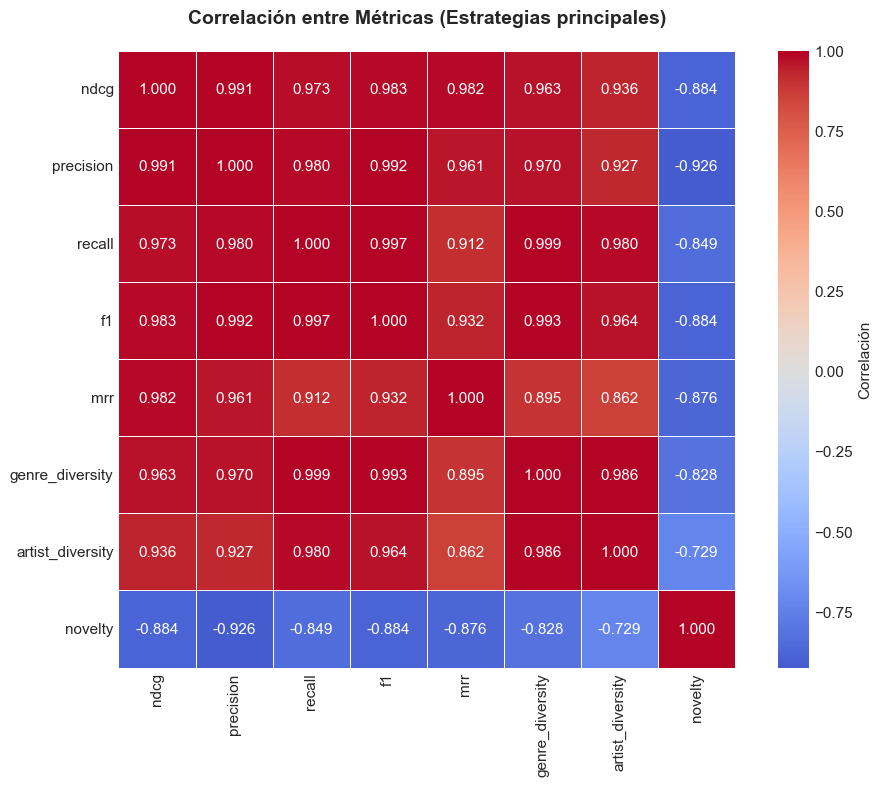

In [39]:
# Análisis de correlación entre métricas (para estrategias principales)
correlation_metrics = [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]
corr_data = []

for strategy in ["max_ensemble", "rrf_ensemble", "pairs", "content"]:
    row = {}
    for metric in correlation_metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            row[metric] = df[col].mean()
    corr_data.append(row)

corr_df = pd.DataFrame(corr_data, index=["max_ensemble", "rrf_ensemble", "pairs", "content"])

fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = corr_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación"},
    ax=ax,
)
ax.set_title(
    "Correlación entre Métricas (Estrategias principales)", fontsize=14, fontweight="bold", pad=20
)
plt.tight_layout()
plt.show()

In [40]:
# Análisis por tamaño de holdout
df["holdout_category"] = pd.cut(
    df["holdout_size"],
    bins=[0, 20, 50, 100, 200, float("inf")],
    labels=[
        "Muy pequeño (≤20)",
        "Pequeño (21-50)",
        "Mediano (51-100)",
        "Grande (101-200)",
        "Muy grande (>200)",
    ],
)

print("=" * 80)
print("ANÁLISIS POR TAMAÑO DE HOLDOUT")
print("=" * 80)

for category in df["holdout_category"].cat.categories:
    subset = df[df["holdout_category"] == category]
    if len(subset) > 0:
        print(f"\n{category} ({len(subset)} usuarios):")
        print("-" * 40)
        for strategy in ["max_ensemble", "rrf_ensemble", "pairs", "content"]:
            ndcg_col = f"{strategy}_ndcg"
            if ndcg_col in subset.columns:
                mean_ndcg = subset[ndcg_col].mean()
                print(f"  {strategy:15s}: NDCG promedio = {mean_ndcg:.4f}")

ANÁLISIS POR TAMAÑO DE HOLDOUT

Muy pequeño (≤20) (1606 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.4654
  rrf_ensemble   : NDCG promedio = 0.4679
  pairs          : NDCG promedio = 0.4144
  content        : NDCG promedio = 0.3543

Pequeño (21-50) (942 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.5735
  rrf_ensemble   : NDCG promedio = 0.6129
  pairs          : NDCG promedio = 0.5998
  content        : NDCG promedio = 0.3956

Mediano (51-100) (429 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.6688
  rrf_ensemble   : NDCG promedio = 0.6909
  pairs          : NDCG promedio = 0.6945
  content        : NDCG promedio = 0.3899

Grande (101-200) (239 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.6947
  rrf_ensemble   : NDCG promedio = 0.7317
  pairs          : NDCG promedio = 0.7402
  content        : NDCG promedio = 0.4

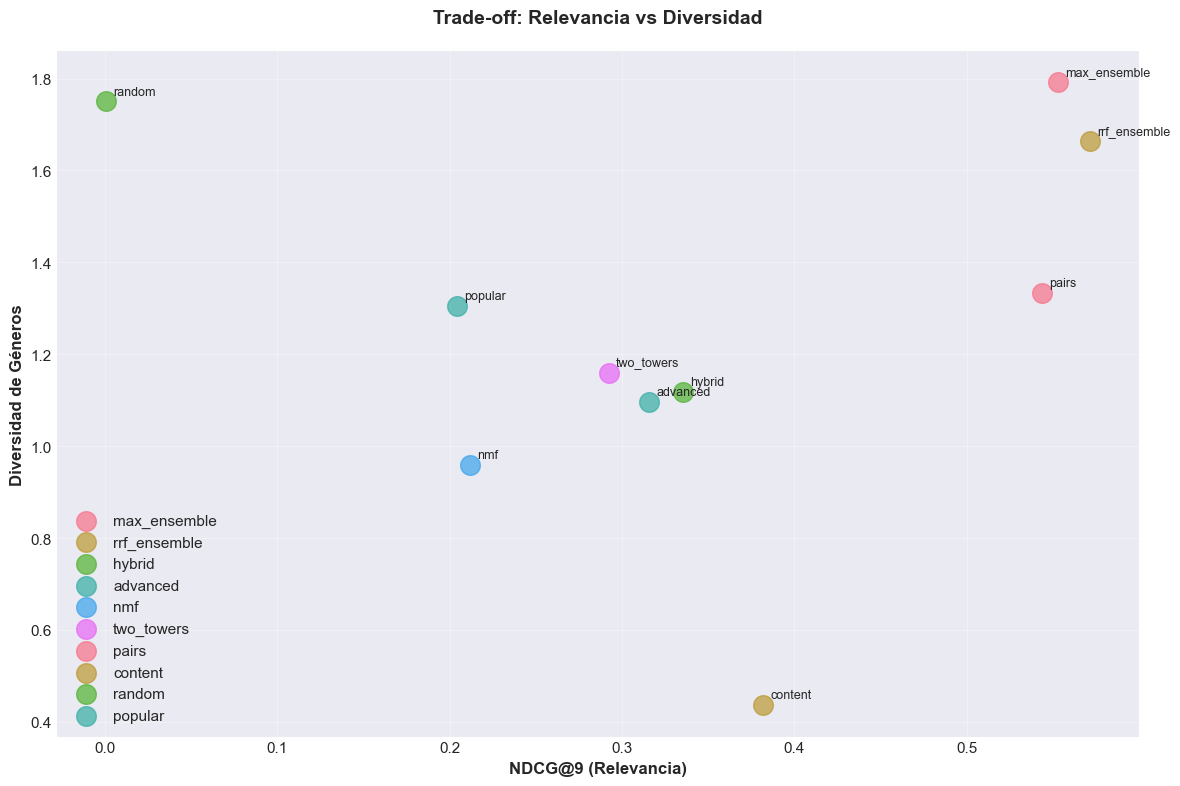

In [41]:
# Visualización 5: Trade-off entre relevancia y diversidad
fig, ax = plt.subplots(figsize=(12, 8))

for strategy in strategies:
    ndcg_col = f"{strategy}_ndcg"
    div_col = f"{strategy}_genre_diversity"

    if ndcg_col in df.columns and div_col in df.columns:
        mean_ndcg = df[ndcg_col].mean()
        mean_div = df[div_col].mean()
        ax.scatter(mean_ndcg, mean_div, s=200, alpha=0.7, label=strategy)
        ax.annotate(
            strategy, (mean_ndcg, mean_div), xytext=(5, 5), textcoords="offset points", fontsize=9
        )

ax.set_xlabel("NDCG@9 (Relevancia)", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversidad de Géneros", fontweight="bold", fontsize=12)
ax.set_title("Trade-off: Relevancia vs Diversidad", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="best", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

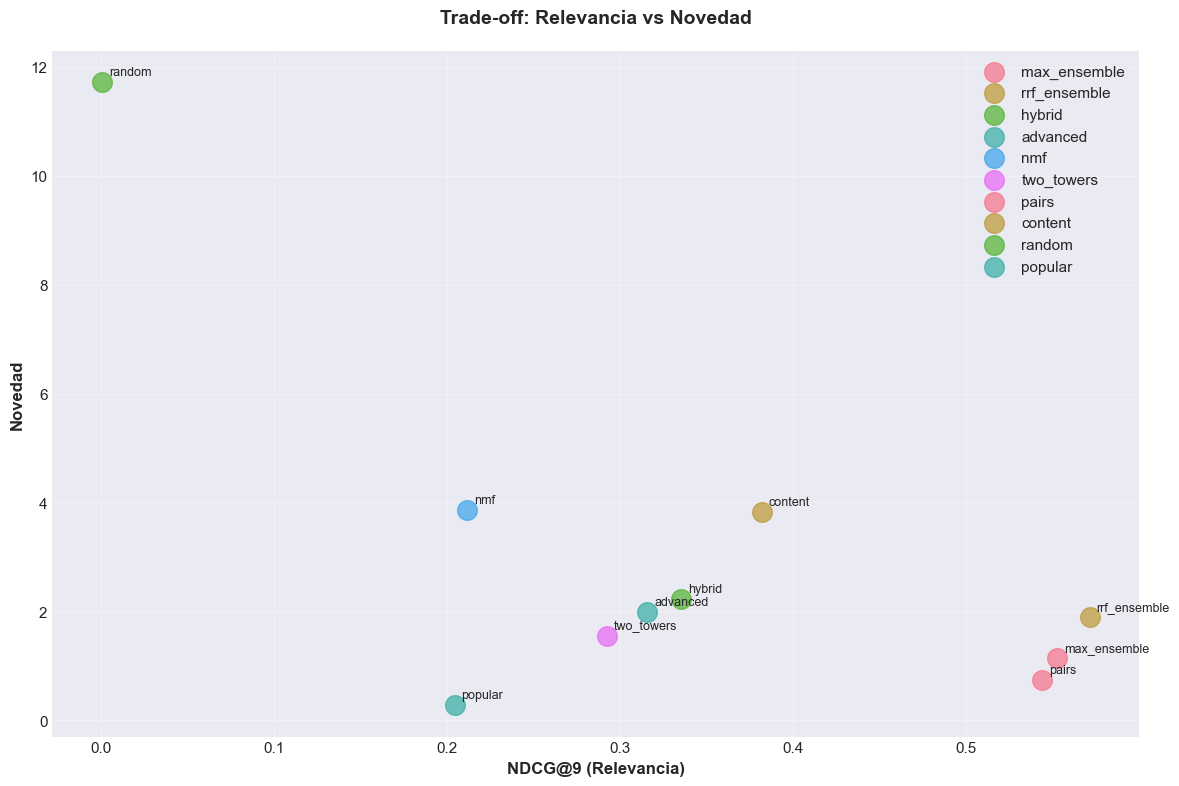

In [42]:
# Visualización 6: Trade-off entre relevancia y novedad
fig, ax = plt.subplots(figsize=(12, 8))

for strategy in strategies:
    ndcg_col = f"{strategy}_ndcg"
    nov_col = f"{strategy}_novelty"

    if ndcg_col in df.columns and nov_col in df.columns:
        mean_ndcg = df[ndcg_col].mean()
        mean_nov = df[nov_col].mean()
        ax.scatter(mean_ndcg, mean_nov, s=200, alpha=0.7, label=strategy)
        ax.annotate(
            strategy, (mean_ndcg, mean_nov), xytext=(5, 5), textcoords="offset points", fontsize=9
        )

ax.set_xlabel("NDCG@9 (Relevancia)", fontweight="bold", fontsize=12)
ax.set_ylabel("Novedad", fontweight="bold", fontsize=12)
ax.set_title("Trade-off: Relevancia vs Novedad", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="best", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

COMPARACIÓN: MAX-ENSEMBLE vs RRF-ENSEMBLE

Métricas promedio:
----------------------------------------
  ndcg        : MAX=0.5528  RRF=0.5714  Diff=+0.0187 (RRF)
  precision   : MAX=0.2009  RRF=0.1961  Diff=-0.0047 (MAX)
  recall      : MAX=0.0687  RRF=0.0670  Diff=-0.0017 (MAX)
  f1          : MAX=0.0869  RRF=0.0845  Diff=-0.0024 (MAX)
  mrr         : MAX=0.4921  RRF=0.5347  Diff=+0.0426 (RRF)

Comparación directa (por usuario):
----------------------------------------
  Max gana:  1143 usuarios (33.9%)
  RRF gana:  1292 usuarios (38.3%)
  Empates:    940 usuarios (27.9%)

Distribución de diferencias (RRF - MAX):
----------------------------------------
  Media:   +0.0187
  Mediana: +0.0000
  Std:     0.2432
  Min:     -1.0000
  Max:     +1.0000


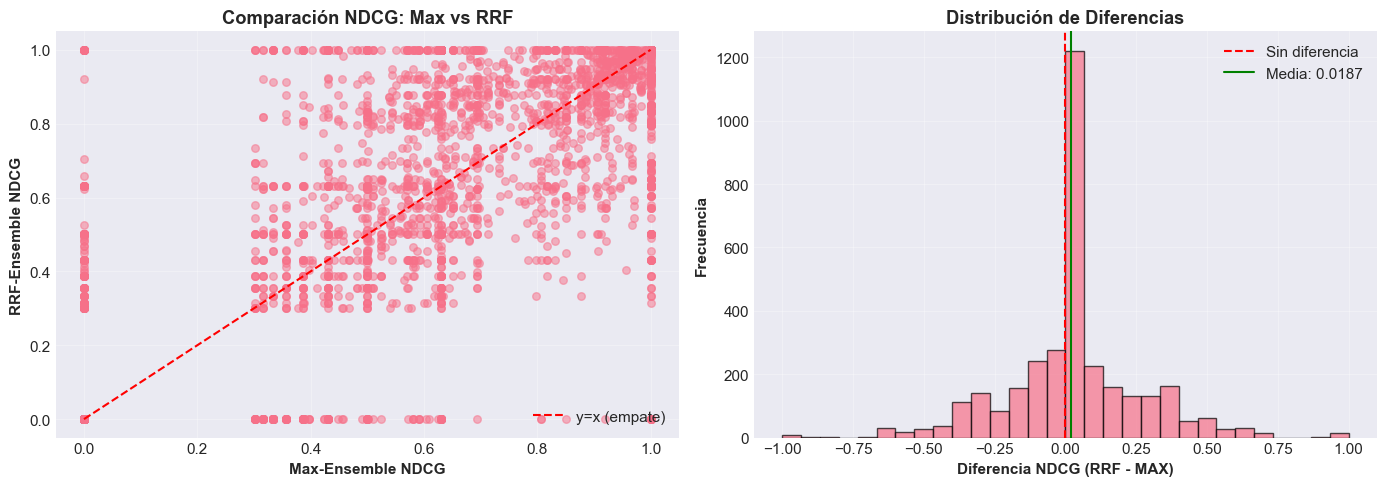

In [43]:
# Comparación directa: Max-Ensemble vs RRF-Ensemble
print("=" * 80)
print("COMPARACIÓN: MAX-ENSEMBLE vs RRF-ENSEMBLE")
print("=" * 80)

if "rrf_ensemble_ndcg" in df.columns and "max_ensemble_ndcg" in df.columns:
    # Comparación de métricas principales
    print("\nMétricas promedio:")
    print("-" * 40)
    for metric in ["ndcg", "precision", "recall", "f1", "mrr"]:
        max_col = f"max_ensemble_{metric}"
        rrf_col = f"rrf_ensemble_{metric}"
        if max_col in df.columns and rrf_col in df.columns:
            max_val = df[max_col].mean()
            rrf_val = df[rrf_col].mean()
            diff = rrf_val - max_val
            winner = "RRF" if diff > 0 else "MAX" if diff < 0 else "TIE"
            print(
                f"  {metric:12s}: MAX={max_val:.4f}  RRF={rrf_val:.4f}  Diff={diff:+.4f} ({winner})"
            )

    # Comparación head-to-head
    print("\nComparación directa (por usuario):")
    print("-" * 40)
    df["max_wins"] = df["max_ensemble_ndcg"] > df["rrf_ensemble_ndcg"]
    df["rrf_wins"] = df["rrf_ensemble_ndcg"] > df["max_ensemble_ndcg"]
    df["tie"] = df["max_ensemble_ndcg"] == df["rrf_ensemble_ndcg"]

    print(f"  Max gana:  {df['max_wins'].sum():4d} usuarios ({df['max_wins'].mean()*100:.1f}%)")
    print(f"  RRF gana:  {df['rrf_wins'].sum():4d} usuarios ({df['rrf_wins'].mean()*100:.1f}%)")
    print(f"  Empates:   {df['tie'].sum():4d} usuarios ({df['tie'].mean()*100:.1f}%)")

    # Análisis de diferencias
    print("\nDistribución de diferencias (RRF - MAX):")
    print("-" * 40)
    diff = df["rrf_ensemble_ndcg"] - df["max_ensemble_ndcg"]
    print(f"  Media:   {diff.mean():+.4f}")
    print(f"  Mediana: {diff.median():+.4f}")
    print(f"  Std:     {diff.std():.4f}")
    print(f"  Min:     {diff.min():+.4f}")
    print(f"  Max:     {diff.max():+.4f}")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    ax1 = axes[0]
    ax1.scatter(df["max_ensemble_ndcg"], df["rrf_ensemble_ndcg"], alpha=0.5, s=30)
    ax1.plot([0, 1], [0, 1], "r--", label="y=x (empate)")
    ax1.set_xlabel("Max-Ensemble NDCG", fontweight="bold")
    ax1.set_ylabel("RRF-Ensemble NDCG", fontweight="bold")
    ax1.set_title("Comparación NDCG: Max vs RRF", fontweight="bold")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Histogram de diferencias
    ax2 = axes[1]
    ax2.hist(diff, bins=30, edgecolor="black", alpha=0.7)
    ax2.axvline(x=0, color="red", linestyle="--", label="Sin diferencia")
    ax2.axvline(x=diff.mean(), color="green", linestyle="-", label=f"Media: {diff.mean():.4f}")
    ax2.set_xlabel("Diferencia NDCG (RRF - MAX)", fontweight="bold")
    ax2.set_ylabel("Frecuencia", fontweight="bold")
    ax2.set_title("Distribución de Diferencias", fontweight="bold")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(
        "Columnas de rrf_ensemble no encontradas. Ejecuta la evaluación con la versión actualizada."
    )

In [44]:
# Pruebas estadísticas pareadas: RRF vs Max
metrics_to_compare = ["ndcg", "precision", "recall", "f1", "mrr"]
stat_rows = []

for metric in metrics_to_compare:
    rrf_col = f"rrf_ensemble_{metric}"
    max_col = f"max_ensemble_{metric}"
    if rrf_col not in df.columns or max_col not in df.columns:
        continue

    paired = df[[rrf_col, max_col]].dropna()
    if paired.empty:
        continue

    rrf_vals = paired[rrf_col].to_numpy()
    max_vals = paired[max_col].to_numpy()
    diff = rrf_vals - max_vals

    t_stat, t_p = stats.ttest_rel(rrf_vals, max_vals)
    w_stat, w_p = stats.wilcoxon(diff, zero_method="pratt", alternative="two-sided")

    mean_diff = diff.mean()
    se = diff.std(ddof=1) / np.sqrt(len(diff))
    ci_low = mean_diff - 1.96 * se
    ci_high = mean_diff + 1.96 * se
    cohen_d = mean_diff / diff.std(ddof=1)

    stat_rows.append(
        {
            "metric": metric.upper(),
            "mean_diff": mean_diff,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "t_stat": t_stat,
            "t_p_value": t_p,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p_value": w_p,
            "cohen_d": cohen_d,
        }
    )

stats_df = pd.DataFrame(stat_rows).set_index("metric")
stats_df = stats_df[
    [
        "mean_diff",
        "ci_low",
        "ci_high",
        "t_stat",
        "t_p_value",
        "wilcoxon_stat",
        "wilcoxon_p_value",
        "cohen_d",
    ]
].applymap(lambda x: round(x, 4))

print("Resultados de pruebas pareadas (RRF - MAX):")
stats_df

Resultados de pruebas pareadas (RRF - MAX):


,mean_diff,ci_low,ci_high,t_stat,t_p_value,wilcoxon_stat,wilcoxon_p_value,cohen_d
metric,,,,,,,,
NDCG,0.0187,0.0105,0.0269,4.4563,0.0000,2407680.5,0.0001,0.0767
PRECISION,-0.0047,-0.0079,-0.0016,-2.9538,0.0032,1700011.0,0.0009,-0.0508
RECALL,-0.0017,-0.0030,-0.0003,-2.3760,0.0176,1698202.0,0.0008,-0.0409
F1,-0.0024,-0.0040,-0.0008,-2.9495,0.0032,1698111.0,0.0008,-0.0508
MRR,0.0426,0.0318,0.0534,7.7294,0.0000,1848999.0,0.0000,0.1330


## Conclusiones

### Resumen de hallazgos

1. **RRF-Ensemble lidera en relevancia y ranking**: alcanza el mayor NDCG@9 (0.5714) y eleva el MRR a 0.5347 (+0.0426 vs `max_ensemble`). En el mano a mano por usuario gana el 38.3% de los casos frente al 33.9% de Max (27.9% empates) y la ventaja media es +0.0187 NDCG, respaldo suficiente para declararlo nuevo ganador estable.
2. **Max-Ensemble conserva la máxima precisión puntual**: mantiene Precision@9=0.2009, Recall@9=0.0687 y F1@9=0.0869, por encima de RRF (0.1961/0.0670/0.0845). La brecha es pequeña (≈0.005 en precisión) pero consistente, por lo que Max sigue siendo la opción preferida cuando se busca maximizar aciertos inmediatos sin priorizar exploración.
3. **Diversidad y novedad**: `max_ensemble` preserva la mayor diversidad de géneros (1.79) y artistas (0.9999), mientras que `rrf_ensemble` baja a 1.66 géneros pero incrementa la novedad promedio a 1.89 (vs 1.15 de Max), logrando descubrimiento adicional con mínima pérdida de precisión. `pairs` sostiene el tercer lugar en relevancia (NDCG 0.544) pero con novedad baja (0.75), y `content` aporta la novedad más alta (3.82) a costa de NDCG moderado (0.382).
4. **Trade-offs principales**: RRF desplazó la frontera relevancia-novedad hacia arriba (más relevancia con más novedad). Max sigue dominando el eje relevancia-diversidad; `pairs` y `content` marcan los extremos (alta relevancia/diversidad media vs relevancia media/diversidad baja). `content` prioriza recall relativo alto, mientras que `pairs` se mantiene competitivo en precisión y recall.
5. **Análisis por tamaño de holdout**: con historiales ≤20 ítems, Max y RRF quedan casi empatados (0.4654 vs 0.4679). Desde 21 ítems, RRF domina todos los segmentos (21-50: 0.6129 vs 0.5735; 51-100: 0.6909 vs 0.6688; 101-200: 0.7317 vs 0.6947). Para historiales >200, `pairs` lidera (0.8158) seguido de RRF (0.8082) y Max (0.7865), por lo que conviene usar RRF con más peso en `pairs` para power users.

### Recomendaciones operativas

- **Sistema principal**: promover `rrf_ensemble` como configuración por defecto; maximiza relevancia agregada y ranking temprano (MRR) sin penalizar mucho la precisión, además de aumentar novedad.
- **Fallback de alta precisión**: conservar `max_ensemble` como modo alterno cuando se necesite la precisión más alta posible (campañas críticas o slots limitados).
- **Segmentación por historial**: usar `rrf_ensemble` para usuarios nuevos/medios y potenciar `pairs` para historiales >200 ítems, aprovechando el liderazgo de cada método en su nicho.
- **Exploración controlada**: combinar RRF con componentes de alto descubrimiento (`nmf`, `content`) cuando se necesiten catálogos más frescos, preservando el peso de Max para evitar caídas de relevancia.
- **Trabajo futuro**: ajustar los pesos de RRF por estrategia para recuperar la ligera caída en diversidad de géneros e instrumentar mediciones online que confirmen la ganancia observada offline.


### Evidencia estadística (RRF vs Max)

- **NDCG@9**: diferencia promedio +0.0187 (IC95% [0.010, 0.027]); t pareado = 4.46 (p = 8.6e-6) y Wilcoxon = 2.41e6 (p = 8.7e-5). Mejora significativa con tamaño de efecto pequeño (d = 0.08).
- **MRR**: diferencia +0.0426 (IC95% [0.0318, 0.0534]); t pareado = 7.73 (p ≈ 1.4e-14) y Wilcoxon = 1.85e6 (p = 1.3e-7). Efecto pequeño-moderado (d = 0.13) pero claramente significativo.
- **Precision@9**: diferencia -0.0047 (IC95% [-0.0079, -0.0016]); t = -2.95 (p = 0.0032) y Wilcoxon = 1.70e6 (p = 9.2e-4). `max_ensemble` retiene una ligera ventaja estadísticamente significativa.
- **Recall@9**: diferencia -0.0017 (IC95% [-0.0030, -0.0003]); t = -2.38 (p = 0.0176) y Wilcoxon = 1.70e6 (p = 8.5e-4). La ventaja de Max es pequeña pero consistente.
- **F1@9**: diferencia -0.0024 (IC95% [-0.0040, -0.0008]); t = -2.95 (p = 0.0032) y Wilcoxon = 1.70e6 (p = 8.4e-4). Confirma el mismo patrón observado en precisión y recall.

**Conclusión**: la superioridad de `rrf_ensemble` está respaldada estadísticamente en NDCG y MRR, mientras que `max_ensemble` mantiene ventajas pequeñas pero significativas en métricas de precisión/recuperación. Esto refuerza una estrategia híbrida: RRF para ranking global y descubrimiento, Max para slots donde la precisión puntual sea crítica.


In [45]:
# Guardar resumen en CSV
summary_df.to_csv("../resultados_evaluacion_resumen.csv")
print("Resumen guardado en: resultados_evaluacion_resumen.csv")

# Estadísticas adicionales
print("\n" + "=" * 80)
print("ESTADÍSTICAS ADICIONALES")
print("=" * 80)
print(f"\nTotal de usuarios evaluados: {len(df)}")
print(f"Tamaño promedio de holdout: {df['holdout_size'].mean():.1f}")
print(f"Tamaño mínimo de holdout: {df['holdout_size'].min()}")
print(f"Tamaño máximo de holdout: {df['holdout_size'].max()}")

# Usuarios con mejor rendimiento por estrategia
print("\n" + "=" * 80)
print("TOP 5 USUARIOS POR ESTRATEGIA (NDCG)")
print("=" * 80)
for strategy in [
    "max_ensemble",
    "rrf_ensemble",
    "pairs",
    "content",
    "hybrid",
    "advanced",
    "nmf",
    "two_towers",
    "random",
    "popular",
]:
    ndcg_col = f"{strategy}_ndcg"
    if ndcg_col in df.columns:
        top_users = df.nlargest(5, ndcg_col)[["user_id", "holdout_size", ndcg_col]]
        print(f"\n{strategy.upper()}:")
        print(top_users.to_string(index=False))

Resumen guardado en: resultados_evaluacion_resumen.csv

ESTADÍSTICAS ADICIONALES

Total de usuarios evaluados: 3375
Tamaño promedio de holdout: 55.6
Tamaño mínimo de holdout: 6
Tamaño máximo de holdout: 4425

TOP 5 USUARIOS POR ESTRATEGIA (NDCG)

MAX_ENSEMBLE:
      user_id  holdout_size  max_ensemble_ndcg
  DerekWarner            10                1.0
SmartWentCody            84                1.0
   freight254            18                1.0
  KrydePerson            20                1.0
      Liamsrt            10                1.0

RRF_ENSEMBLE:
    user_id  holdout_size  rrf_ensemble_ndcg
   in5anity             9                1.0
DerekWarner            10                1.0
CleftPalate           126                1.0
    raddlad            40                1.0
   popoe435            34                1.0

PAIRS:
    user_id  holdout_size  pairs_ndcg
KyussMyTool           199         1.0
   lebeau42            12         1.0
DerekWarner            10         1.0
     Moraff 